# **NephroSense — CKD Stage Prediction Platform**
## Notebook 2: Model Training, Evaluation & Explainability

**Author:** Mushahid Hussain  
**Dataset:** Processed CKD Dataset (4,000 records, 26 features)  
**Objective:** Train multiple ML models, track experiments with MLflow, 
evaluate performance, and implement SHAP explainability for production use.


## **Section 0 — Import Libraries**

In [1]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

## **Section 1 — Data Loading & Train/Test Split**

- Processed dataset loaded: 4,000 rows × 27 columns
- Target column: `ckd_stage` (0–5, six-class classification)
- Features: 26 clinical and lifestyle columns
- Train/Test split: 80/20 with `stratify=y` to preserve class distribution
- Training set: 3,200 samples | Test set: 800 samples

In [2]:
BASE_DIR = Path.cwd().parent

df = pd.read_csv(BASE_DIR / "data" / "processed" / "processed_ckd.csv")
print("Data shape:", df.shape)
df.head()

Data shape: (4000, 27)


,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,...,diet_balanced,diet_high protein,diet_low salt,alcohol_daily,alcohol_never,alcohol_occasionally,weight_changes_gain,weight_changes_loss,weight_changes_stable,ckd_stage
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,...,0,1,0,1,0,0,0,0,1,3
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,...,0,1,0,1,0,0,0,1,0,3
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,...,0,0,1,1,0,0,0,0,1,5
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,...,0,0,1,0,1,0,0,0,1,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,...,1,0,0,0,0,1,1,0,0,3


In [3]:
X = df.drop(columns=['ckd_stage'])
y = df['ckd_stage']

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, y_train.shape)

Train shape: (3200, 26) (3200,)


##  **Section 2— Baseline Model Comparison**

In [4]:
pipelines = {
    "LogisticRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "DecisionTreeClassifier": Pipeline([
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'RandomForestClassifier': Pipeline([
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'GradientBoostingClassifier': Pipeline([
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    'XGBClassifier': Pipeline([
        ('model', XGBClassifier(random_state=42))
    ]),
    'svm': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ]),
    "NaviesBayes": Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),
    "KNeighborsClassifier": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ])

}

In [5]:
# Define Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Cross Validation + Full Evaluation ===\n")

# Dictionaries to store evaluation results and trained models
cv_results = {}
trained_pipelines = {}

# Train and evaluate each machine learning pipeline
for name, pipeline in pipelines.items():
    
    # Train the model on the full training dataset
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    # Perform cross-validation using the weighted F1-score
    f1_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )
    
    

    # Generate predictions on the test dataset
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_scores.mean()

    # Store the average cross-validation F1-score
    cv_results[name] = f1

    # Display the evaluation results
    print(f"{'='*45}")
    print(f"Model          : {name}")
    print(f"CV F1 Score    : {f1:.4f}")
    print(f"Accuracy       : {acc:.4f}")


=== Cross Validation + Full Evaluation ===

Model          : LogisticRegression
CV F1 Score    : 0.9395
Accuracy       : 0.9387
Model          : DecisionTreeClassifier
CV F1 Score    : 0.9781
Accuracy       : 0.9888
Model          : RandomForestClassifier
CV F1 Score    : 0.9805
Accuracy       : 0.9812
Model          : GradientBoostingClassifier
CV F1 Score    : 0.9874
Accuracy       : 0.9925
Model          : XGBClassifier
CV F1 Score    : 0.9867
Accuracy       : 0.9862
Model          : svm
CV F1 Score    : 0.7934
Accuracy       : 0.8300
Model          : NaviesBayes
CV F1 Score    : 0.7599
Accuracy       : 0.7125
Model          : KNeighborsClassifier
CV F1 Score    : 0.3526
Accuracy       : 0.3488


## **Baseline Model Comparison — Results**

Eight models evaluated using Stratified 5-Fold Cross-Validation 
with Weighted F1-Score as the primary metric (chosen due to class imbalance).

Top 3 performers:
- GradientBoosting: CV F1 = 0.9874 | Accuracy = 0.9925
- XGBoost: CV F1 = 0.9867 | Accuracy = 0.9862  
- RandomForest: CV F1 = 0.9805 | Accuracy = 0.9812

Decision: XGBoost selected as primary algorithm — near-identical 
performance to GradientBoosting but significantly faster (5.8s vs 16.2s).
SVM, Naive Bayes, and KNN performed poorly on this dataset even after feature scaling.

## **Section 3 — MLflow Experiment Tracking Setup**

- Tracking URI: SQLite database (`mlflow.db`)
- Experiment name: `NephroSense`
- Three versions trained and tracked:
  - V1: RandomForest (baseline)
  - V2: XGBoost default (champion)
  - V3: XGBoost tuned via RandomizedSearchCV (challenger)

## *V1 Random Forest (Baseline)*

In [6]:
import mlflow
import mlflow.sklearn

# Set MLflow tracking database and experiment
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("NephroSense")

with mlflow.start_run(run_name="V1_RandomForest"):

    # Create and train the Random Forest model
    model = RandomForestClassifier(
        random_state=42,
        n_estimators=100
    )
    model.fit(X_train, y_train)

    # Generate predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate overall model performance
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Generate the classification report
    report = classification_report(y_test, y_pred)

    # Generate the report as a dictionary for stage-wise metrics
    report_dict = classification_report(y_test,y_pred,output_dict=True)

    # Log model parameters
    mlflow.log_param("n_estimators", 100)

    # Log F1-score for each stage
    for stage, metrics in report_dict.items():
        if isinstance(metrics, dict):
            mlflow.log_metric(f"f1_stage_{stage}", metrics['f1-score'])
                
    # Save the full classification report as a text artifact
    mlflow.log_text(report, "classification_report.txt")

    # Log overall performance metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)

    # Log the trained model to MLflow
    mlflow.sklearn.log_model(model , name="v1_model")
    # Save the model locally as a PKL file
    joblib.dump(model, BASE_DIR / "models" / "v1_random_forest.pkl")
    

    # Print results for quick verification
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Weighted: {f1:.4f}")
    print(f"Classification Report:\n{report}")

Accuracy: 0.9812
F1 Weighted: 0.9789
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.48      0.65        25
           1       0.89      1.00      0.94       109
           2       1.00      1.00      1.00       201
           3       1.00      1.00      1.00       173
           4       0.99      1.00      0.99       159
           5       1.00      0.98      0.99       133

    accuracy                           0.98       800
   macro avg       0.98      0.91      0.93       800
weighted avg       0.98      0.98      0.98       800



## **Observation**
| Metric | Value |
|--------|-------|
| Accuracy | 0.9812 |
| F1 Weighted | 0.9789 |
| Stage 0 F1 | 0.649 ← weak |

Note: Stage 0 (Healthy class) F1 is significantly lower (0.649) 
due to class imbalance — only 125 healthy samples in dataset.
Model saved: `models/v1_random_forest.pkl`

## *V2 XGBoost Default (Champion/Production Model)*

In [7]:
with mlflow.start_run(run_name="V2_XGBoost"):

    # Create and train the XGBoost model
    model = XGBClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Generate predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate overall model performance
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Generate the classification report
    report = classification_report(y_test, y_pred)

    # Convert the report into a dictionary for stage-wise metrics
    report_dict = classification_report(y_test,y_pred, output_dict=True)

    # Save the full classification report as a text artifact
    mlflow.log_text(report, "classification_report.txt")

    # Log F1-score for each stage
    for stage, metrics in report_dict.items():
        if isinstance(metrics, dict):
            mlflow.log_metric(f"f1_stage_{stage}", metrics['f1-score'])
            
    # Log overall performance metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)

    # Log the trained XGBoost model to MLflow
    mlflow.xgboost.log_model(model, name="v2_model")

    # Save the model locally as a PKL file
    joblib.dump(model, BASE_DIR / "models" / "v2_xgboost.pkl")

    # Print results for quick verification
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Weighted: {f1:.4f}")
    print(f"Classification Report:\n{report}")

Accuracy: 0.9862
F1 Weighted: 0.9862
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        25
           1       0.97      0.98      0.98       109
           2       1.00      1.00      1.00       201
           3       0.99      0.99      0.99       173
           4       0.98      0.98      0.98       159
           5       0.99      0.99      0.99       133

    accuracy                           0.99       800
   macro avg       0.98      0.97      0.98       800
weighted avg       0.99      0.99      0.99       800



## **Observation**
| Metric | Value |
|--------|-------|
| Accuracy | 0.9862 |
| F1 Weighted | 0.9862 |
| Stage 0 F1 | 0.917 |

XGBoost achieved better Stage 0 performance than Random Forest on this dataset.
Stage 0 F1 improved from 0.649 (V1) to 0.917 — significant improvement.
**Selected as Production/Champion model.**
Model saved: `models/v2_xgboost.pkl`

## *V3: XGBoost Tuned (Challenger/Backup Model)*

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Create RandomizedSearchCV for hyperparameter tuning
tuned_search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Search for the best hyperparameter combination
tuned_search.fit(X_train, y_train)

# Display the best parameters and cross-validation score
print(tuned_search.best_params_)
print(tuned_search.best_score_)

{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
0.9858198750978338


In [9]:
with mlflow.start_run(run_name="V3_XGBoost_Tuned"):

    # Get the best model and hyperparameters from RandomizedSearchCV

    best_model = tuned_search.best_estimator_
    best_params = tuned_search.best_params_

    # Refit the best model on the full training data
    best_model.fit(X_train, y_train)
    # Generate predictions on the test data
    y_pred = best_model.predict(X_test)

    # Calculate overall model performance
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    # Generate the classification report
    report = classification_report(y_test, y_pred)
    # Convert the report into a dictionary for stage-wise metrics
    report_dict = classification_report(y_test, y_pred, output_dict=True)

    # Save the full classification report as a text artifact
    mlflow.log_text(report, "classification_report.txt")
    # Log F1-score for each stage
    for stage, metrics in report_dict.items():
        if isinstance(metrics, dict):
            mlflow.log_metric(f"f1_stage_{stage}", metrics['f1-score'])
    # Log the best hyperparameters
    mlflow.log_params(best_params)
    # Log overall performance metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)
    # Log the tuned XGBoost model to MLflow
    mlflow.xgboost.log_model(best_model, name="v3_model")
    # Save the tuned model locally as a PKL file
    joblib.dump(best_model, BASE_DIR / "models" / "v3_xgboost_tuned.pkl")

    # Print final results
    print(f"Best Params: {best_params}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Weighted: {f1:.4f}")

Best Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Accuracy: 0.9838
F1 Weighted: 0.9836


## **Observation**
Best parameters from RandomizedSearchCV:
- n_estimators: 200, max_depth: 5
- learning_rate: 0.1, subsample: 0.7, colsample_bytree: 0.8

| Metric | Value |
|--------|-------|
| Accuracy | 0.9838 |
| F1 Weighted | 0.9836|
| Stage 0 F1 | 0.917 |

Note: V3 slightly underperforms V2 — default XGBoost params were 
near-optimal for this dataset. RandomizedSearchCV explores limited 
combinations and may miss the global optimum.
**Selected as Challenger/Rollback model.**
Model saved: `models/v3_xgboost_tuned.pkl`

## **Section 4 — Confusion Matrix Analysis**

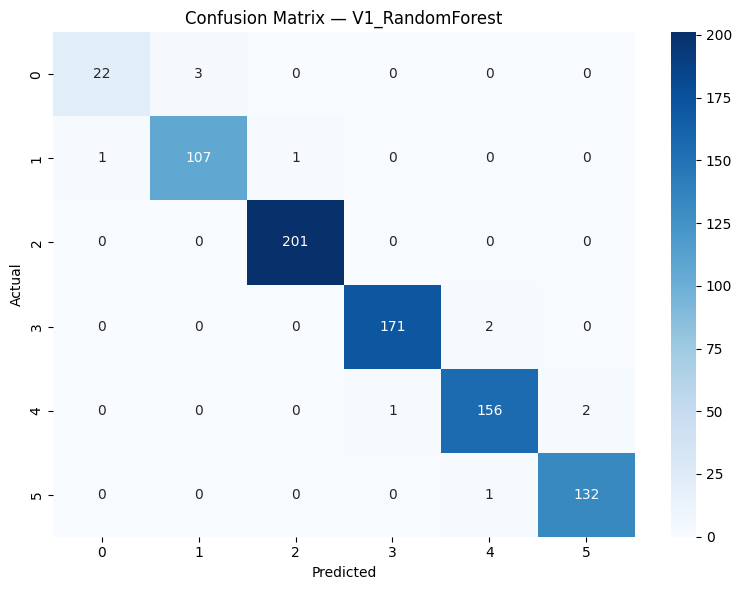

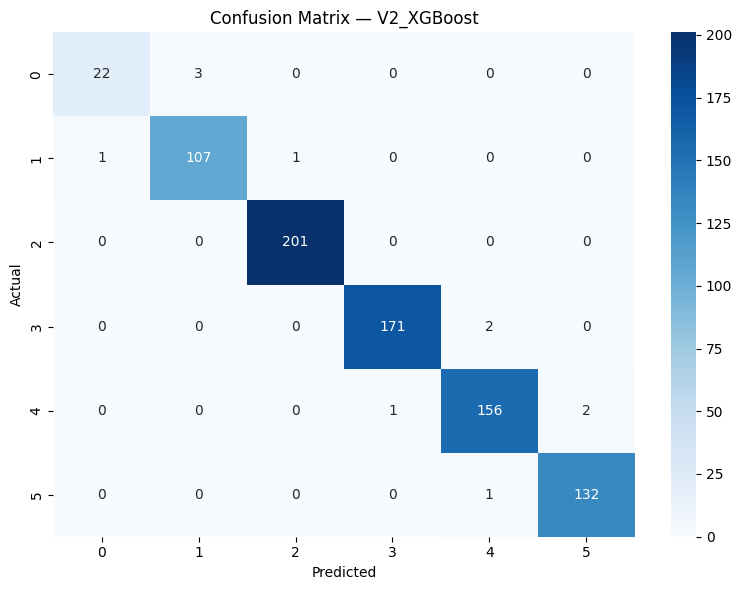

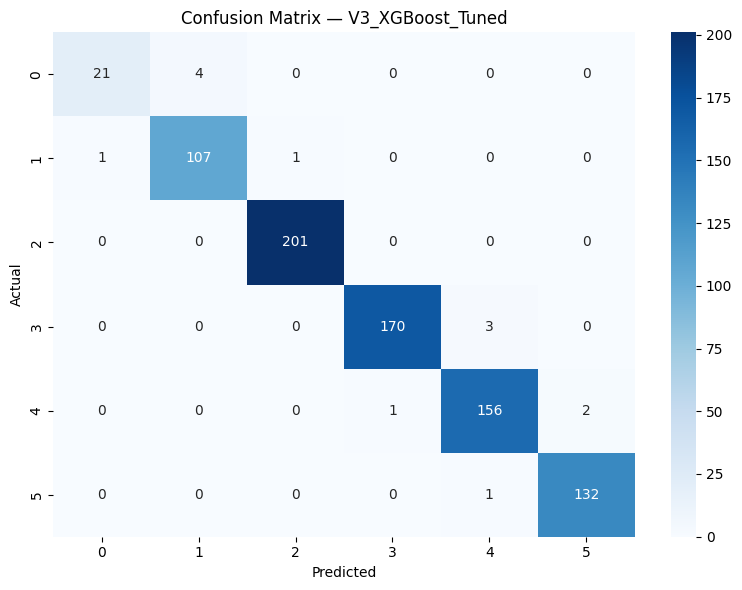

In [10]:
models_dict = {
    'V1_RandomForest': model,
    'V2_XGBoost': model,
    'V3_XGBoost_Tuned': best_model
}

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1,2,3,4,5],
                yticklabels=[0,1,2,3,4,5])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(BASE_DIR / "assets" / f"confusion_matrix_{name}.png", 
                dpi=150, bbox_inches='tight')
    plt.show()

## **Observation**
All three models show strong diagonal dominance — correct predictions.

Key observations:
- Stage 2 (most common): Perfect prediction in all models (201/201)
- Stage 0 (healthy, rarest): 22/25 correct — 3 misclassified as Stage 1
- V1 RandomForest Stage 0 recall weakest — confirms F1 Stage 0 = 0.649
- V2 and V3 identical confusion patterns except Stage 3 (V3: 170 vs V2: 171)

Clinical implication: Stage 0 misclassification (healthy → Stage 1) 
is less dangerous than missing a severe stage — acceptable trade-off.

## **Section 5 — Final Model Selection**

| Version | Model | F1 Weighted | Accuracy | Role |
|---------|-------|-------------|----------|------|
| V1 | RandomForest | 0.9789 | 0.9812 | Baseline |
| **V2** | **XGBoost** | **0.9862** | **0.9862** | **Production** |
| V3 | XGBoost Tuned | 0.9836 | 0.9838 | Challenger |

Rollback Strategy: V2 → V3 → V1 (cascade)
Evaluation Metric: Weighted F1-Score (chosen due to class imbalance)

## **Section 6 — Model Registry**
Both production-relevant models registered in MLflow Model Registry:
- `NephroSense_Champion` → V2 XGBoost | Tag: Production
- `NephroSense_Challenger` → V3 XGBoost Tuned | Tag: Staging

Registry enables version control, stage management, and 
seamless model loading in FastAPI without hardcoded paths.

In [11]:
from mlflow import MlflowClient
client = MlflowClient()

v2_run_id = "1a6a65d79a1e42b29062cb16fd685e04"
v3_run_id = "7168041077d848ba84a8ea1dd0f207b3"

mlflow.register_model(
    model_uri=f"runs:/{v2_run_id}/v2_model",
    name="NephroSense_Champion"
)

client.set_registered_model_tag(
    "NephroSense_Champion",
    "stage",
    "Production"
)

mlflow.register_model(
    model_uri=f"runs:/{v3_run_id}/v3_model",
    name="NephroSense_Challenger"
)

client.set_registered_model_tag(
    "NephroSense_Challenger",
    "stage",
    "staging"
)

Successfully registered model 'NephroSense_Champion'.
2026/08/29 08:51:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 1a6a65d79a1e42b29062cb16fd685e04 has no artifacts at artifact path 'v2_model', registering model based on models:/m-a5424b61ca354f319dbb4b25b70635e5 instead
Created version '1' of model 'NephroSense_Champion'.
Successfully registered model 'NephroSense_Challenger'.
2026/08/29 08:51:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 7168041077d848ba84a8ea1dd0f207b3 has no artifacts at artifact path 'v3_model', registering model based on models:/m-e145ce87254b46168217fb1187fa6423 instead
Created version '1' of model 'NephroSense_Challenger'.


## **Section 7 — SHAP Explainability**

In [12]:
import shap
# Create a SHAP TreeExplainer object for our XGBoost model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)
# Check the shape of SHAP values
print("SHAP values shape:", shap_values.shape)
# Check the shape of test data
print("X_test shape:", X_test.shape)

SHAP values shape: (800, 26, 6)
X_test shape: (800, 26)


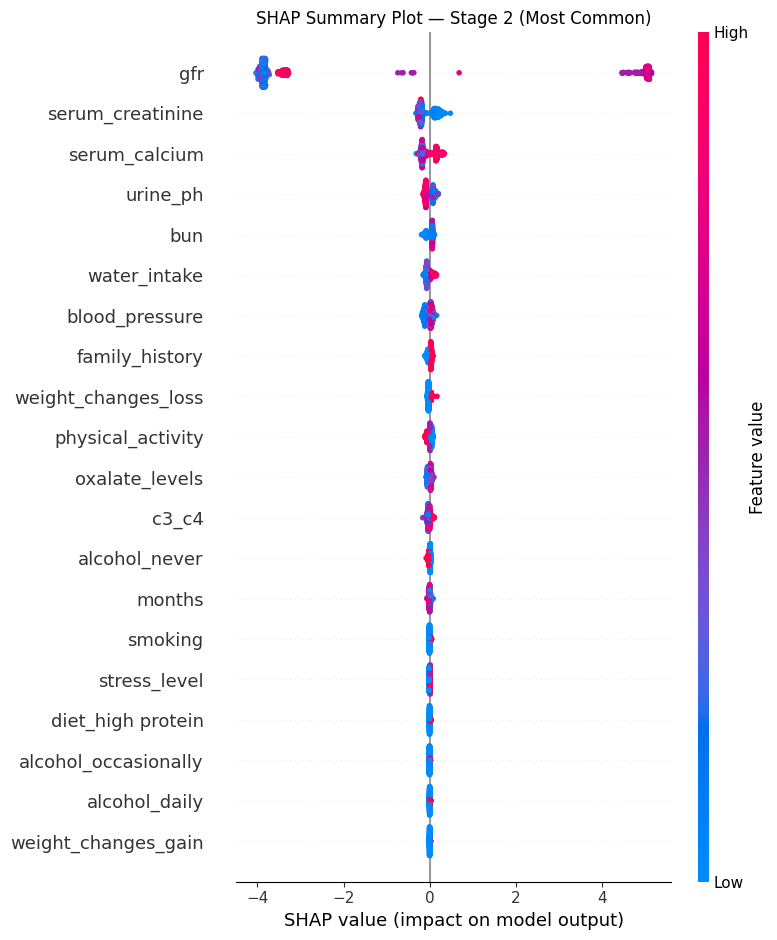

In [13]:
# Create a SHAP summary plot for Class 2 (Stage 2)
shap.summary_plot(
    shap_values[:, :, 2],
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False
)
# Add a title to the plot
plt.title("SHAP Summary Plot — Stage 2 (Most Common)")
plt.tight_layout() # Adjust the layout
# Save the plot as an image
plt.savefig(BASE_DIR / "assets" / "shap_summary_v2.png",
            dpi=150, bbox_inches='tight')
plt.show() # Display the plot

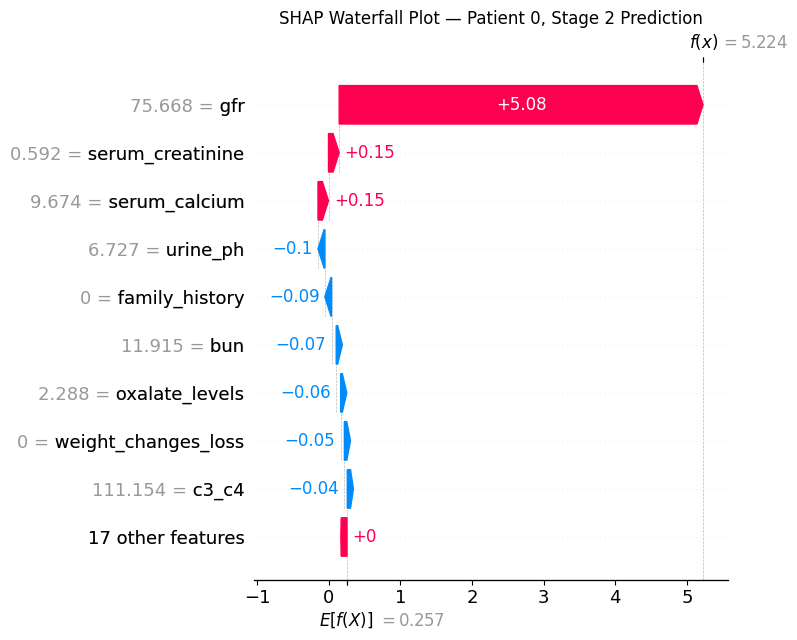

In [14]:
patient_idx = 0
stage_idx = 2  
explanation = shap.Explanation(
    values=shap_values[patient_idx, :, stage_idx],
    base_values=explainer.expected_value[stage_idx],
    data=X_test.iloc[patient_idx],
    feature_names=X_test.columns.tolist()
)

# Create a SHAP waterfall plot for Patient 0 and Stage 2
shap.plots.waterfall(explanation, show=False)

# Add a title to the plot
plt.title("SHAP Waterfall Plot — Patient 0, Stage 2 Prediction")

plt.tight_layout()

# Save the plot as an image
plt.savefig(BASE_DIR / "assets" / "shap_waterfall_v2.png",dpi=150,bbox_inches='tight')

# Display the plot
plt.show()

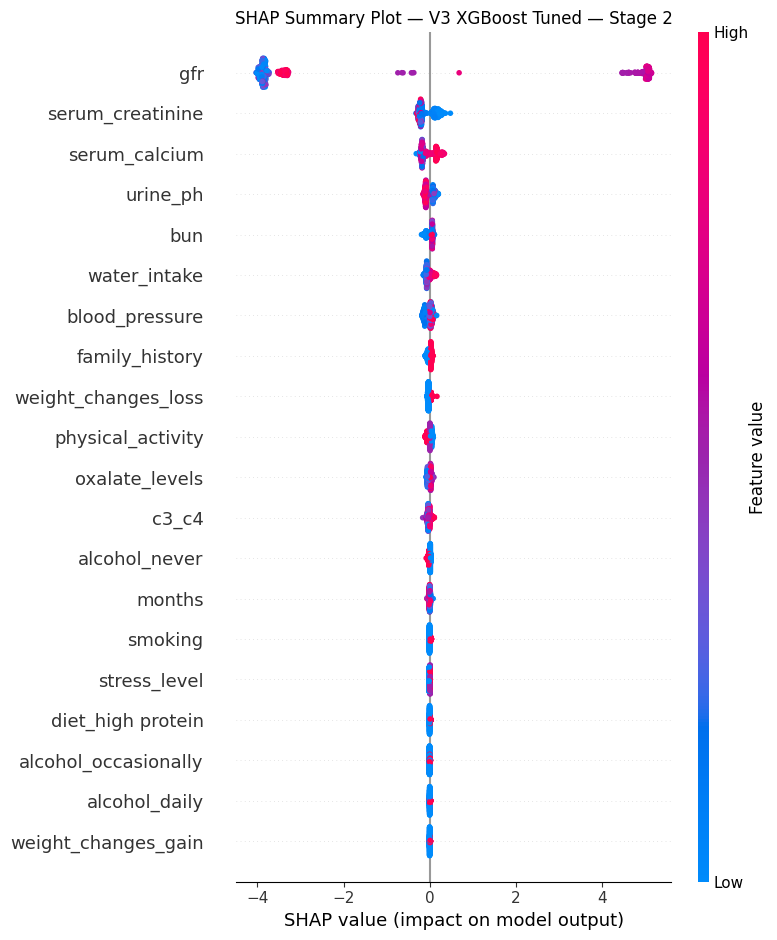

In [15]:
# Create a SHAP TreeExplainer object for our XGBoost Tuned v3 model.
explainer_v3 = shap.TreeExplainer(best_model)
shap_values_v3 = explainer_v3.shap_values(X_test)

# Create a SHAP summary plot for Class 2 (Stage 2)
shap.summary_plot(
    shap_values_v3[:, :, 2],
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot — V3 XGBoost Tuned — Stage 2")
plt.tight_layout()
plt.savefig(BASE_DIR / "assets" / "shap_summary_v3.png",dpi=150, bbox_inches='tight')
plt.show()

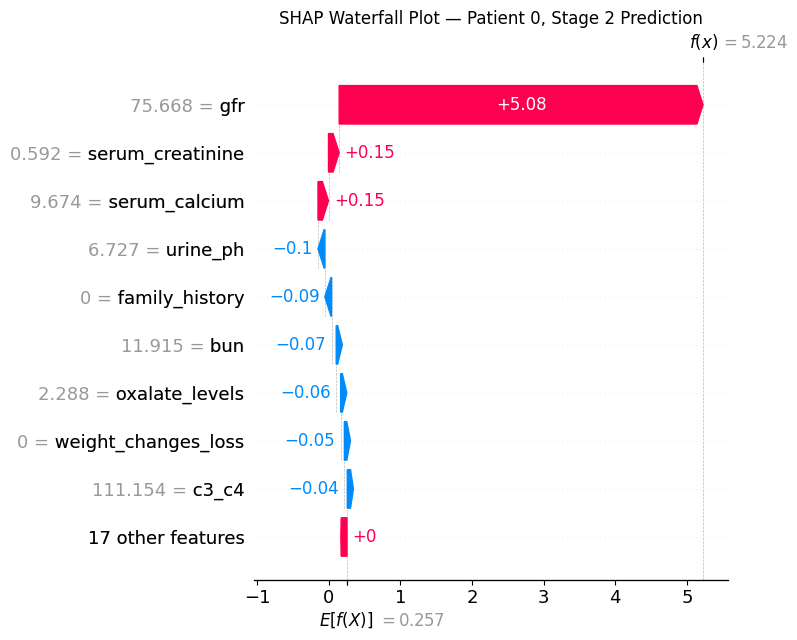

In [16]:
patient_idx = 0
stage_idx = 2

explanation_v3 = shap.Explanation(
    values=shap_values_v3[patient_idx, :, stage_idx],
    base_values=explainer_v3.expected_value[stage_idx],
    data=X_test.iloc[patient_idx],
    feature_names=X_test.columns.tolist()
)

# Create a SHAP waterfall plot for Patient 0 and Stage 2
shap.plots.waterfall(explanation_v3, show=False)

plt.title("SHAP Waterfall Plot — Patient 0, Stage 2 Prediction")
plt.tight_layout()
plt.savefig(BASE_DIR / "assets" / "shap_waterfall_v3.png",dpi=150, bbox_inches='tight')
plt.show()

## **SHAP Explainability (XAI)**
SHAP (SHapley Additive exPlanations) applied to V2 (Champion) and V3 (Challenger).

**Key Finding — GFR is the dominant predictor:**
- SHAP value: +5.2 for Stage 2 prediction
- Medically correct: GFR 60–89 = Stage 2 range (Moderate CKD)
- Low GFR pushes prediction toward Stage 4/5

**Feature Importance Order (Stage 2):**
GFR > serum_creatinine > serum_calcium > urine_ph > bun

**Production use:** SHAP waterfall will be calculated per-patient 
in FastAPI and displayed in the UI.

In [17]:
import joblib

# V2 explainer save
joblib.dump(explainer, BASE_DIR / "models" / "shap_explainer_v2.pkl")

# V3 explainer save 
joblib.dump(explainer_v3, BASE_DIR / "models" / "shap_explainer_v3.pkl")

print("Explainers saved!")

Explainers saved!


## Notebook 02 — Complete

| # | Step | Description |
|---|------|-------------|
| 01 | Data Loading | 4,000 rows, 26 features |
| 02 | Train/Test Split | 80/20 Stratified |
| 03 | Baseline Comparison | 8 models evaluated |
| 04 | V1 — RandomForest | Baseline model |
| 05 | V2 — XGBoost | Champion — Production |
| 06 | V3 — XGBoost Tuned | Challenger — Staging |
| 07 | MLflow Tracking | All runs logged |
| 08 | Model Registry | Champion + Challenger registered |
| 09 | Confusion Matrix | All 3 versions analyzed |
| 10 | SHAP Analysis | Summary + Waterfall plots |

**Next Step:** FastAPI Backend → `app/main.py`